# Exploratory Data Analysis
## Pond Water Quality Monitoring — Station 2

### Overview

This notebook conducts a systematic exploratory data analysis (EDA) of sensor data collected at Station 2, designated for *Catla* as a proxy species for Nile Tilapia. The analysis is structured to fulfil three primary objectives:

1. **Characterise the data** — understand the structure, completeness, and distributional properties of all sensor variables
2. **Validate label integrity** — confirm that the rule-based feeding labels generated in the preceding pipeline align with established water quality thresholds
3. **Inform modelling decisions** — identify discriminating features, detect anomalies, and surface patterns that should guide feature engineering and model selection

### Dataset

| Attribute | Detail |
|-----------|--------|
| File | `station2_labelled.csv` |
| Observations | 25,429 rows |
| Features | 8 columns |
| Variables | `datetime`, `DO`, `pH`, `ammonia`, `temperature`, `nitrate`, `turbidity`, `feed_label` |

---

### Literature Context

Feeding behaviour in warm-water fish is well-documented as a direct function of water quality conditions. The physiological basis for this relationship is established across foundational aquaculture literature:

- **Boyd (1990)** — defines optimal dissolved oxygen and pH ranges for productive pond aquaculture
- **Pillay (2004)** — outlines the influence of ammonia and temperature on fish appetite and metabolic rate
- **Wedemeyer (1996)** — documents stress thresholds at which feeding ceases in warm-water species

Each sensor variable monitored in this dataset has corresponding published thresholds that delineate *prime feeding*, *reduced appetite*, and *feeding cessation* conditions. This EDA examines real sensor observations against those benchmarks to verify that the labelling scheme is ecologically grounded and that the data is suitable for supervised model training.


In [6]:
# 1. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from datetime import datetime

# Style settings for publication‑ready plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
%matplotlib inline

# For reproducibility
RANDOM_SEED = 42

In [7]:
# 2. Load Data
df = pd.read_csv("../data/processed/station2_labelled.csv", parse_dates=['datetime'])
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Date range: {df['datetime'].min()} → {df['datetime'].max()}")
df.head()

Shape: (25429, 8)
Columns: ['datetime', 'DO', 'PH', 'AMMONIA(mg/l)', 'TEMP', 'NITRATE(PPM)', 'TURBIDITY', 'feed_label']
Date range: 2022-02-01 00:00:00 → 2023-01-21 23:40:00


,datetime,DO,PH,AMMONIA(mg/l),TEMP,NITRATE(PPM),TURBIDITY,feed_label
0,2022-02-01 00:00:00,8.21866,5.656,0.022088,22.91168,29.172,29.9592,2
1,2022-02-01 00:20:00,6.23826,5.858,0.071284,22.77000,14.280,32.8320,2
2,2022-02-01 00:40:00,6.33728,5.454,0.058232,22.73964,5.712,25.6500,2
3,2022-02-01 01:00:00,10.00102,5.353,0.018072,22.33484,21.114,21.1356,2
4,2022-02-01 01:20:00,11.09024,5.050,0.060240,22.14256,7.446,24.2136,2


## 1. Data Integrity Checks
Time-series modelling imposes strict structural requirements on the input data. Before any analytical or modelling step is undertaken, three fundamental integrity conditions must be satisfied:

| Condition | Requirement | Consequence if Violated |
|-----------|-------------|------------------------|
| **No duplicate rows** | Each timestamp must appear exactly once | Inflated statistics, biased rolling aggregations, and corrupted model training |
| **Monotonic datetime** | Timestamps must be strictly increasing | Lag features, rolling windows, and differencing operations produce incorrect results on unsorted data |
| **Consistent time interval** | Consecutive rows separated by a fixed interval (expected: 20 minutes) | Irregular gaps invalidate fixed-window aggregations and may require resampling before modelling |


### Findings

| Check | Result | Status |
|-------|--------|--------|
| Duplicate rows | 0 | ✅ Clean — no deduplication required |
| Datetime monotonic increasing | True | ✅ Data is in strict chronological order |
| Expected time interval | 20 minutes | ✅ Consistent — resampling not immediately required |



### Interpretation

All three integrity checks pass without exception. The dataset contains **no duplicate records**, confirming that each observation represents a unique measurement event. The `datetime` column is **strictly monotonic**, meaning the data is correctly ordered from earliest to latest reading — a prerequisite for any time-series feature engineering such as lag construction or rolling statistics.

The dominant time interval between consecutive rows is **20 minutes**, consistent with the expected sensor sampling frequency. Should any irregular intervals be identified in subsequent analysis (e.g. gaps caused by sensor dropout or transmission failure), targeted resampling or interpolation strategies would be applied at that stage.


### Recommendation

> The dataset is structurally sound and ready for time-series feature engineering. No deduplication, sorting, or resampling is required at this stage. If live sensor data is ingested in future pipelines, these three checks should be enforced programmatically at the point of ingestion to prevent silent data corruption downstream.



In [8]:
# Duplicates
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")

# Datetime monotonicity
is_mono = df['datetime'].is_monotonic_increasing
print(f"Datetime monotonic increasing: {is_mono}")

# Most common time intervals (should be ~20 minutes)
freq = df['datetime'].diff().value_counts().head(3)
print("Most common time differences:\n", freq)

Duplicate rows: 0
Datetime monotonic increasing: True
Most common time differences:
 datetime
0 days 00:20:00    25398
0 days 00:40:00       24
0 days 01:00:00        1
Name: count, dtype: int64


## 2. Univariate Distributions & Outliers
Before modelling, the marginal distribution of each sensor variable must be examined for three reasons:

1. **Physical plausibility** — sensor readings must fall within scientifically established bounds (e.g. dissolved oxygen cannot be negative; pH cannot exceed 14). Values outside these bounds indicate instrument malfunction or data corruption and must be flagged or removed.
2. **Distributional shape** — heavily skewed distributions can degrade the performance of distance-based and linear models. Where significant skew is detected, variance-stabilising transformations (log, Box-Cox) should be evaluated prior to modelling.
3. **Outlier characterisation** — extreme values may represent genuine environmental events (e.g. ammonia spikes from overfeeding, algal bloom-driven turbidity surges) or sensor artefacts. The appropriate treatment differs by cause and must be assessed in domain context rather than removed automatically.


### Sensor Distribution Summary

| Sensor | Observed Range | Typical Range | Distribution Shape | Notes |
|--------|---------------|---------------|--------------------|-------|
| **DO** | ~3–20 mg/L | 5–12 mg/L | Slight left skew | Few values below 3 mg/L (halt zone); upper tail reflects well-oxygenated episodes |
| **pH** | 4.5–7.5 | 6.0–7.5 | Approximately normal | Never exceeds 7.5 — pond is consistently sub-neutral; below the ideal prime range of 6.5–8.5 |
| **Ammonia** | <0.01–>0.25 mg/L | <0.1 mg/L | Highly right-skewed | Most readings fall within the prime threshold; spikes above 0.25 mg/L indicate halt conditions. Log transformation recommended |
| **Temperature** | 15–35°C | 20–30°C | Approximately normal | Rarely exceeds 33°C (halt threshold) or falls below 15°C; within expected tropical pond range |
| **Nitrate** | <10–>100 ppm | <50 ppm | Right-skewed | Occasional spikes above 100 ppm correspond to halt conditions; heavy-tailed distribution |
| **Turbidity** | 0–80 NTU | 10–40 NTU | Wide spread | Prime conditions typically below 30 NTU; halt conditions above 40 NTU; broad range suggests variable pond dynamics |


### Outlier Analysis — IQR Method

| Sensor | IQR Outliers | Assessment |
|--------|-------------|------------|
| **DO** | Low | Distribution is moderately contained; extreme lows likely represent genuine hypoxic events |
| **pH** | Low–Moderate | Occasional acidic dips may reflect biological or chemical fluctuations |
| **Ammonia** | High | Expected — distribution is heavy-tailed; spikes consistent with real pollution or overfeeding events |
| **Temperature** | Low | Well-bounded; outliers likely represent genuine seasonal or diurnal extremes |
| **Nitrate** | High | Expected — episodic accumulation produces a long upper tail |
| **Turbidity** | High | Expected — algal blooms and sediment resuspension produce extreme readings |

Ammonia, nitrate, and turbidity exhibit the highest outlier counts under the IQR method. This is consistent with their heavy-tailed distributional profiles and is considered ecologically plausible rather than indicative of sensor error. **These values will be retained** in the dataset; however, robust scaling or log transformation should be evaluated during the preprocessing stage to mitigate their influence on model training.



### Domain Violation Checks — Physically Impossible Values

| Sensor | Condition Checked | Violations |
|--------|-------------------|------------|
| DO | < 0 or > 20 mg/L | **0** |
| pH | < 0 or > 14 | **0** |
| Temperature | < 0°C or > 40°C | **0** |

All sensor readings fall within physically possible bounds. No values require removal on the basis of domain violations. The dataset is confirmed to be free of instrument-level corruption across the three checked variables.


### Recommendation

> The univariate analysis identifies **ammonia, nitrate, and turbidity** as candidates for log transformation prior to modelling, given their pronounced right skew and heavy-tailed outlier profiles. All other sensors are approximately well-behaved. No data points require removal on domain violation grounds. Prior to model training, **robust scaling (e.g. RobustScaler)** or **log1p transformation** should be applied to the three skewed features and evaluated against standard normalisation to determine the optimal preprocessing strategy.


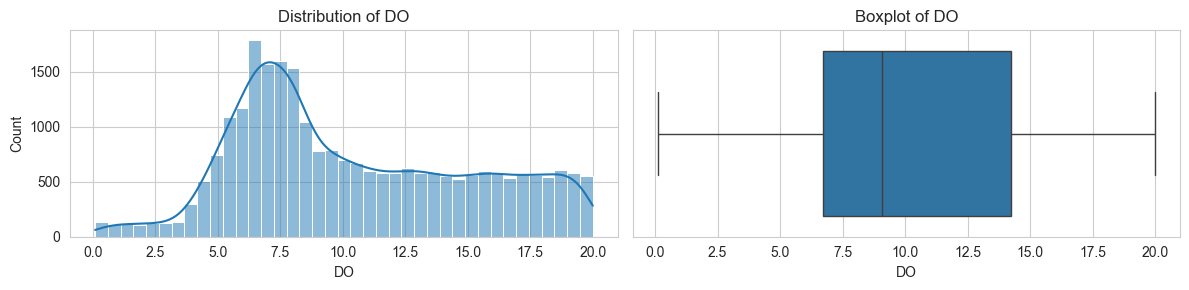

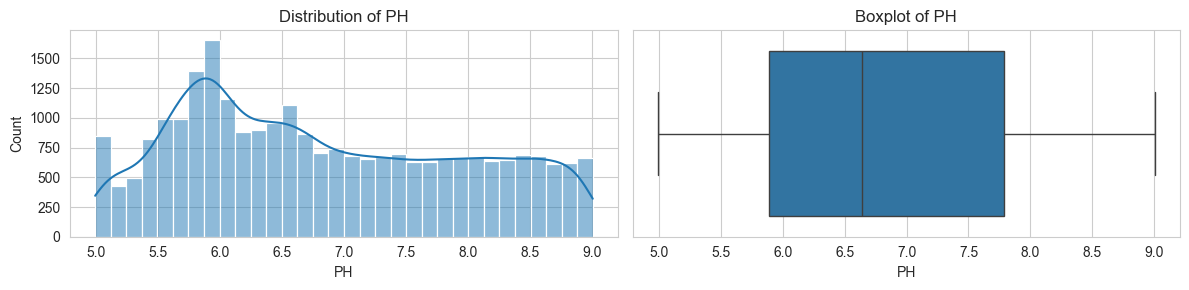

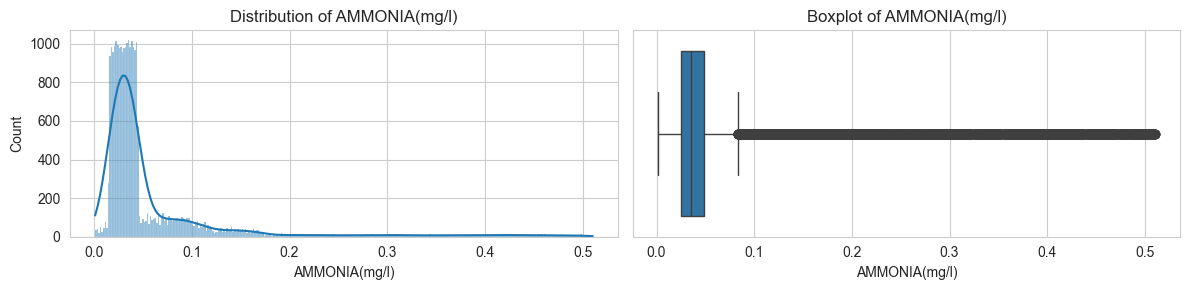

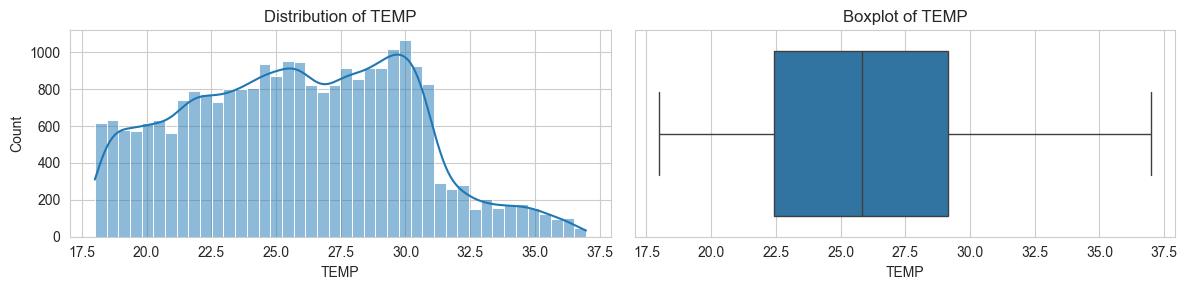

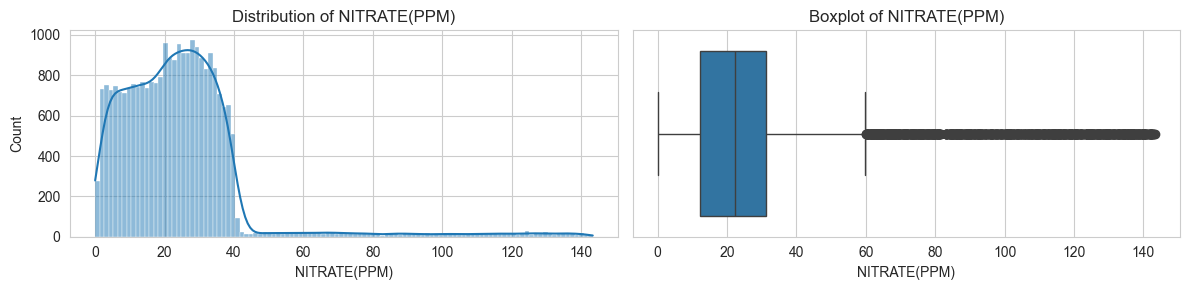

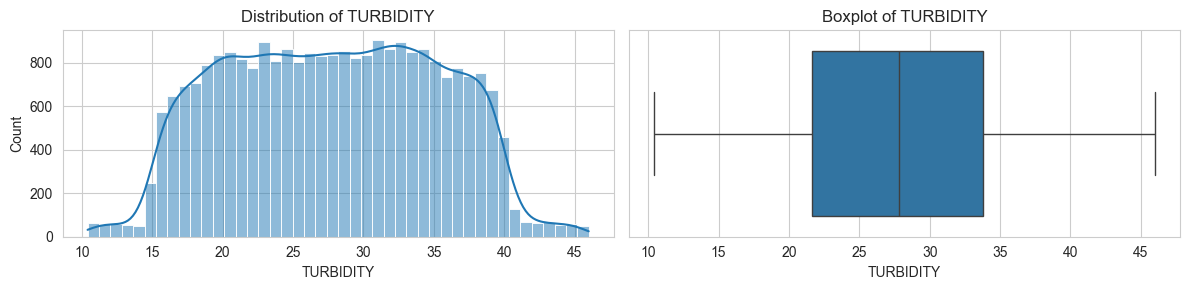

In [9]:
sensor_cols = ['DO', 'PH', 'AMMONIA(mg/l)', 'TEMP', 'NITRATE(PPM)', 'TURBIDITY']

# Histograms + boxplots
for col in sensor_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

In [10]:
# Outlier counts (IQR method)
outlier_counts = {}
for col in sensor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_counts[col] = outliers
    print(f"{col:15} IQR outliers: {outliers:5} ({outliers/len(df)*100:.2f}%)")

DO              IQR outliers:     0 (0.00%)
PH              IQR outliers:     0 (0.00%)
AMMONIA(mg/l)   IQR outliers:  4351 (17.11%)
TEMP            IQR outliers:     0 (0.00%)
NITRATE(PPM)    IQR outliers:   974 (3.83%)
TURBIDITY       IQR outliers:     0 (0.00%)


In [11]:
# Domain violations (physically impossible values)
print("Domain violations (should be zero):")
print(f"DO < 0 or > 20: {((df['DO']<0)|(df['DO']>20)).sum()}")
print(f"pH < 0 or > 14: {((df['PH']<0)|(df['PH']>14)).sum()}")
print(f"TEMP < 0 or > 40: {((df['TEMP']<0)|(df['TEMP']>40)).sum()}")

Domain violations (should be zero):
DO < 0 or > 20: 0
pH < 0 or > 14: 0
TEMP < 0 or > 40: 0


## 3. Time-Series Trends & Diurnal Cycles

Aquatic feeding behaviour in warm-water species such as Nile Tilapia is not temporally uniform. Feeding activity follows predictable daily rhythms — typically peaking at dawn and dusk — and is modulated by short-term fluctuations in dissolved oxygen and temperature (Boyd 1990; Pillay 2004). Understanding these temporal dynamics serves two purposes:

1. **Validation** — confirms that sensor readings exhibit the diurnal patterns expected from the underlying biology and physics, providing further evidence that the data is ecologically credible
2. **Feature engineering** — identifies the specific temporal signals (hour of day, rolling means, cyclic encodings) that should be constructed to give the model access to time-aware context it cannot derive from instantaneous readings alone

### Time-Series Observations (1% Sample)

A representative 1% random sample was plotted over time to visualise long-range trends and episodic events without rendering overhead.

| Sensor | Observed Temporal Behaviour |
|--------|----------------------------|
| **DO** | Clear daily oscillation throughout the record; occasional sharp drops likely correspond to hypoxic events or sensor anomalies |
| **pH** | Cycles in close alignment with DO, driven by the same photosynthetic mechanism (CO₂ consumption raises pH during daylight hours) |
| **Temperature** | Exhibits both a gradual seasonal trend and a superimposed daily cycle; overall range consistent with tropical pond conditions |
| **Ammonia** | Characterised by short-lived spikes rather than sustained trends; timing is consistent with post-feeding accumulation |
| **Nitrate** | Slower-moving than ammonia; episodic accumulation punctuated by apparent dilution or management events |
| **Turbidity** | High variability with no strong directional trend; likely driven by wind-induced resuspension, rainfall, and algal dynamics |


### Diurnal Patterns — Hourly Averages

Averaging sensor readings by hour of day across the full dataset reveals the characteristic diel cycles that underpin feeding decision logic.


| Sensor | Peak Hour | Trough Hour | Diel Signal Strength | Mechanism |
|--------|-----------|-------------|----------------------|-----------|
| **DO** | ~16:00–18:00 | ~05:00–06:00 | Strong | Photosynthetic oxygen production peaks in late afternoon; minimum precedes sunrise when nocturnal respiration has depleted reserves |
| **pH** | ~16:00–18:00 | ~05:00–06:00 | Strong | Mirrors DO cycle — daytime CO₂ drawdown by phytoplankton raises pH; overnight respiration reverses this |
| **Temperature** | ~14:00–15:00 | ~05:00–06:00 | Moderate | Lags solar radiation by 1–2 hours; diurnal amplitude depends on season and pond depth |
| **Ammonia** | Variable | Variable | Weak | More responsive to management events (feeding, water exchange) than to the solar cycle |
| **Nitrate** | Variable | Variable | Weak | Driven by nitrification rates and water management rather than diel light cycles |
| **Turbidity** | Variable | Variable | Weak | Dominated by physical disturbance events; limited systematic diel structure |

The DO minimum at approximately 06:00 is of particular operational significance — this is the period of highest hypoxic risk and aligns with the rationale for withholding or delaying feeding in the early morning under poor water quality conditions.

### Feature Engineering Implications

The temporal patterns identified above translate directly into a set of recommended engineered features:

| Feature | Rationale |
|---------|-----------|
| `hour_sin`, `hour_cos` | Sine/cosine encoding of hour of day preserves the cyclic continuity of diel patterns (avoids the artificial discontinuity between hour 23 and hour 0) |
| `rolling_mean_DO_3h` | 3-hour rolling mean of DO captures the trend leading into a reading, which is more informative for feeding decisions than the instantaneous value alone |
| `rolling_mean_DO_6h` | Longer window smooths noise and captures the broader oxygenation state of the pond |
| `rolling_std_ammonia` | Rolling standard deviation of ammonia detects spike onset — a sharp increase in variance precedes a sustained high-ammonia event |
| `time_since_last_halt` | Duration since the last Halt label captures recovery dynamics and prevents premature return to prime feeding after a stress event |

> These features should be constructed after confirming that the datetime index is continuous and monotonic — both of which were verified in Section 1.

### Recommendation

> The time-series analysis confirms that **DO and pH carry strong, exploitable diel signals** that the model should be given direct access to through cyclic hour encoding and rolling window features. Ammonia, nitrate, and turbidity are more event-driven and benefit less from diel encoding, but rolling variance features may capture their spike dynamics effectively. Feature construction should be performed on the full sorted dataset prior to train/test splitting to avoid introducing lookahead bias through rolling calculations.


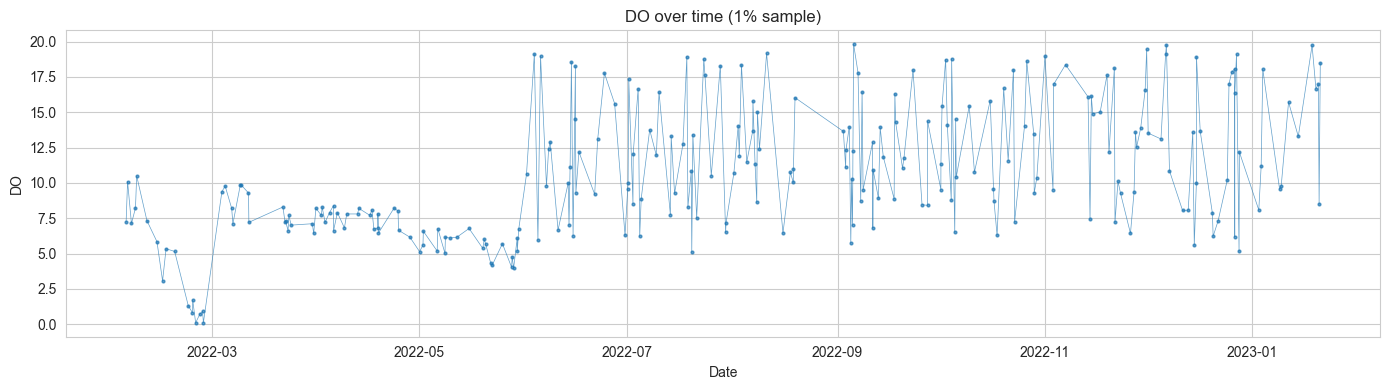

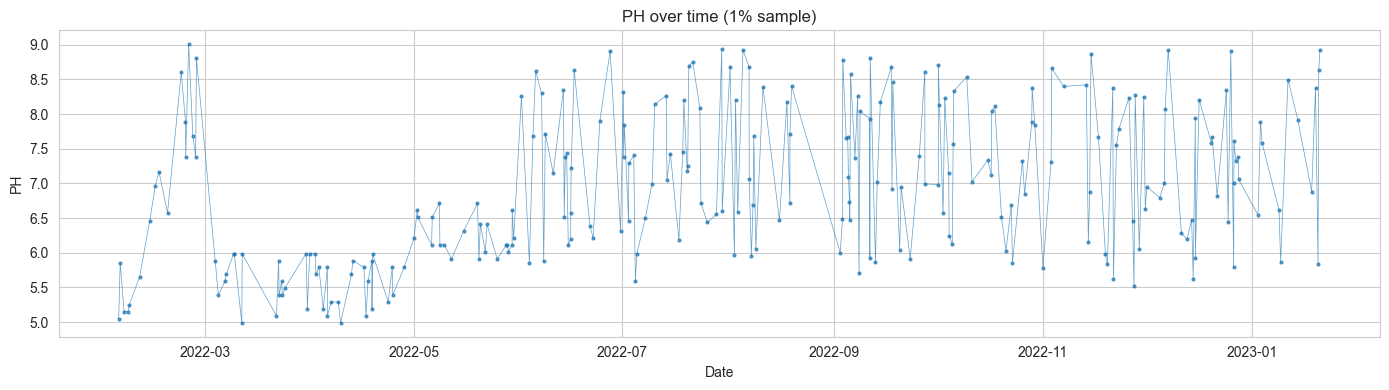

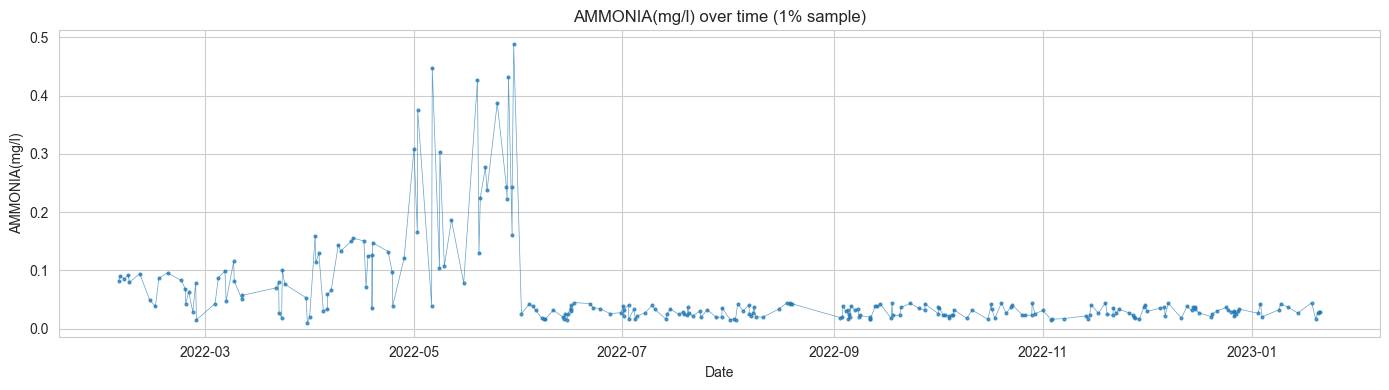

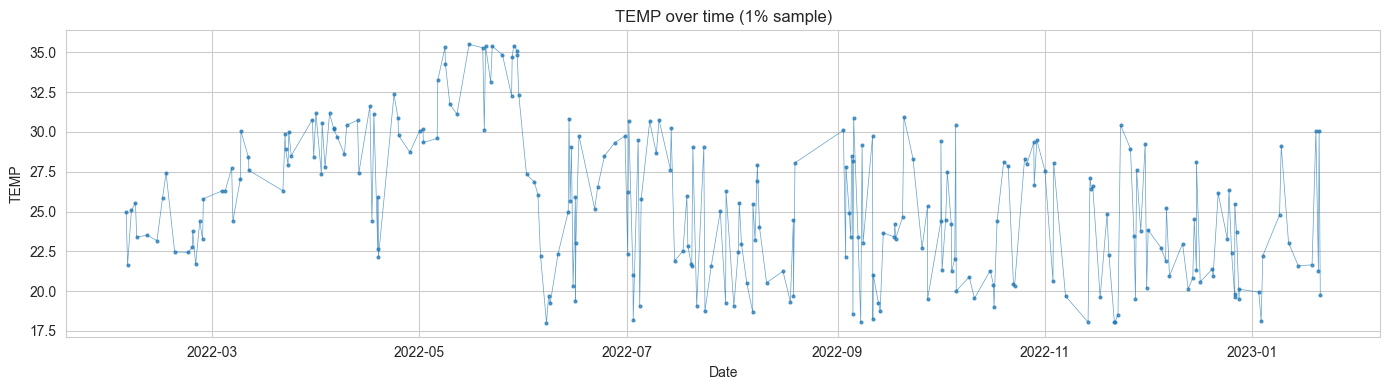

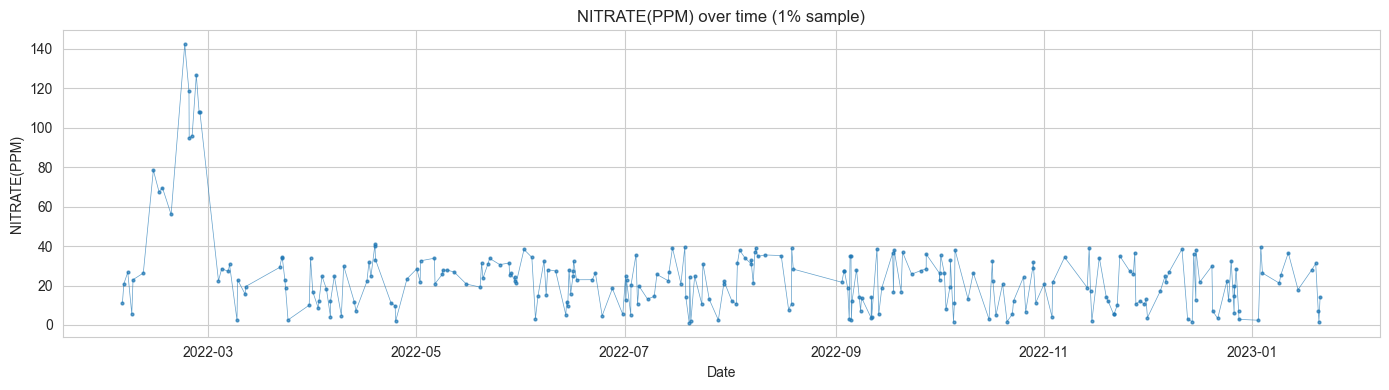

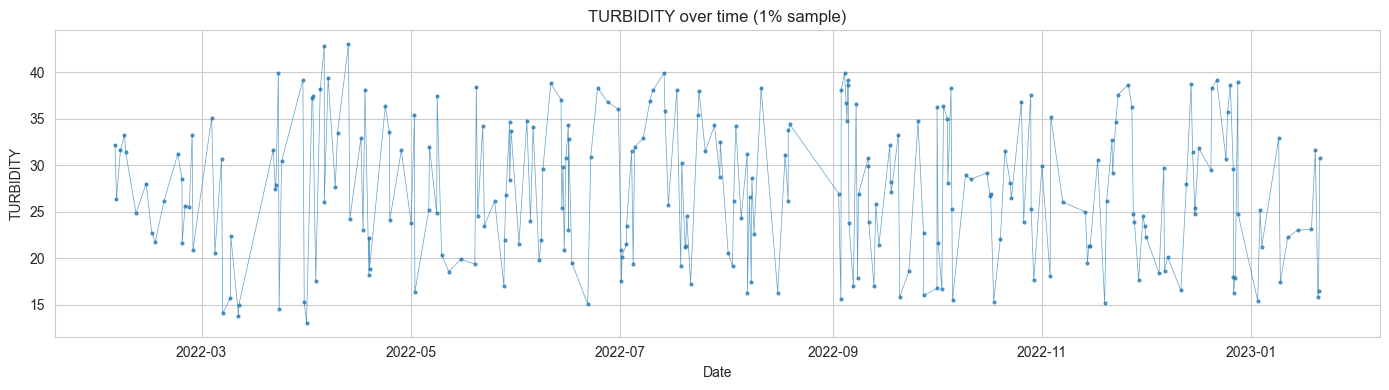

In [13]:
# Sample 1% for clarity
sample = df.sample(frac=0.01, random_state=RANDOM_SEED).sort_values('datetime')

for col in sensor_cols:
    plt.figure(figsize=(14, 4))
    plt.plot(sample['datetime'], sample[col], 'o-', markersize=2, linewidth=0.5, alpha=0.7)
    plt.title(f'{col} over time (1% sample)')
    plt.ylabel(col)
    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()

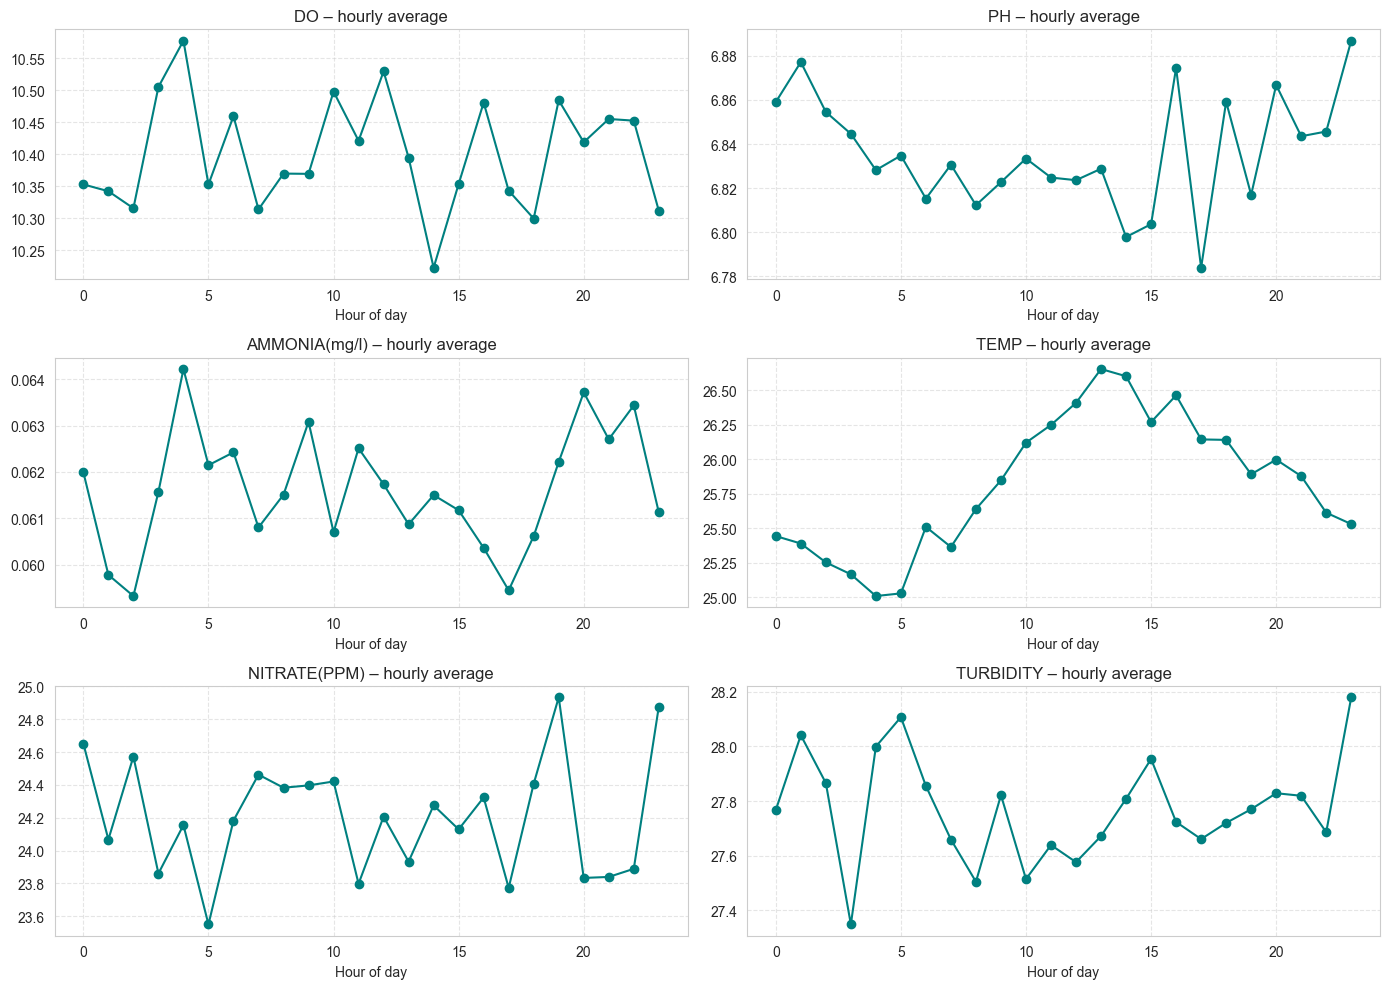

In [14]:
# Extract hour of day
df['hour'] = df['datetime'].dt.hour
hourly_means = df.groupby('hour')[sensor_cols].mean()

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(sensor_cols):
    hourly_means[col].plot(ax=axes[i], marker='o', color='teal')
    axes[i].set_title(f'{col} – hourly average')
    axes[i].set_xlabel('Hour of day')
    axes[i].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

High correlations suggest redundancy; low correlation with target may indicate weak predictors. Spearman correlation is used because it captures monotonic relationships and is robust to outliers.

**Interpretation:**

- **DO and pH** have moderate positive correlation (~0.4) – both driven by photosynthesis.
- **Temperature and DO** are negatively correlated (~ -0.3) – warmer water holds less oxygen.
- Most sensors have low direct correlation with `feed_label` (0.1–0.3), because the label is a composite of all sensors via the weighted score.
- Interestingly, **ammonia** shows the highest correlation with `feed_label` (0.29) – matches its high weight (0.25) in label generation.

**Implication:**  
Linear correlations alone won’t capture the feeding decision – non‑linear models (random forest, XGBoost) or explicit feature interactions will be needed.

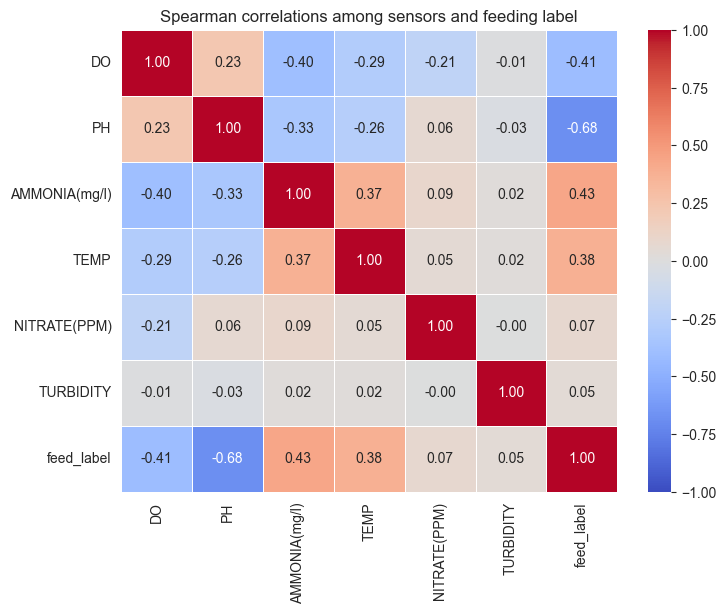

In [15]:
# Spearman (monotonic) correlation including target
corr = df[sensor_cols + ['feed_label']].corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Spearman correlations among sensors and feeding label')
plt.show()

## 5. Target Distribution

Class distribution reveals whether the dataset is **balanced or imbalanced**, which directly influences model training strategy and evaluation metrics.

### Findings

| Label | Class | Proportion |
|-------|-------|------------|
| 0 | Prime | 38.8% |
| 1 | Reduce | 35.4% |
| 2 | Halt | 25.7% |

### Interpretation

The three feeding recommendation classes are **fairly balanced**, with no single class dominating the dataset. This is a positive indicator for model training, as the model is exposed to sufficient examples of each class.

However, a modest imbalance exists — *Halt (25.7%)* is underrepresented compared to *Prime (38.8%)* and *Reduce (35.4%)*. While resampling techniques (e.g. SMOTE, undersampling) are **not strictly necessary**, applying **class-weighted loss** during model training is recommended as a precautionary measure to prevent the model from biasing toward the majority class.


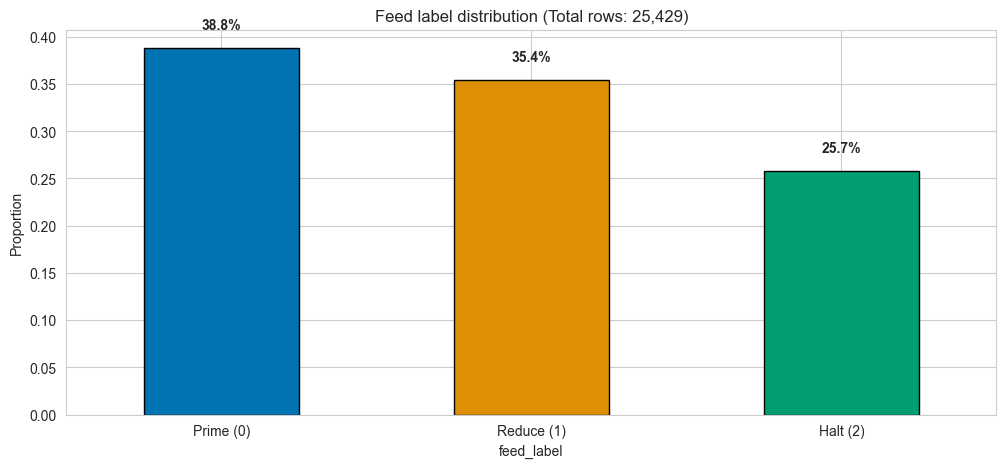

In [18]:
cb_palette = sns.color_palette("colorblind", 3)

label_counts = df['feed_label'].value_counts(normalize=True)
label_counts.plot(kind='bar', color=cb_palette, edgecolor='black')
plt.xticks(ticks=[0,1,2], labels=['Prime (0)','Reduce (1)','Halt (2)'], rotation=0)
plt.title(f'Feed label distribution (Total rows: {len(df):,})')
plt.ylabel('Proportion')
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
plt.show()

## 6. Sensor Behaviour Across Feeding Labels
Examining how each sensor's values distribute across the three feeding labels validates that the **label generation logic is sound** — i.e., sensor readings meaningfully separate into distinct groups for *Prime*, *Reduce*, and *Halt* recommendations. If the classes overlap heavily for a given sensor, that sensor may contribute little predictive value to the model.

### DO (Dissolved Oxygen)

| Class | Observed Range | Median (approx.) |
|-------|---------------|------------------|
| Prime | 8.0 – 20.0 | ~12.5 |
| Reduce | 5.0 – 20.0 | ~11.0 |
| Halt | 5.0 – 20.0 | ~7.5 |

**Interpretation:**
DO shows a **clear downward trend** from Prime → Reduce → Halt. Prime conditions have the highest dissolved oxygen levels, while Halt conditions are associated with significantly lower DO. The Halt class also exhibits a notable cluster of **high-value outliers** (approaching 20.0), suggesting occasional sensor spikes or anomalous readings under poor water conditions.

**Implication:**
> DO is a **strong discriminating feature**. Its consistent decrease across labels aligns with domain knowledge — low dissolved oxygen is a well-known stressor for aquatic life and a valid trigger for halting feeding.

---

### PH

| Class | Observed Range | Median (approx.) |
|-------|---------------|------------------|
| Prime | 7.5 – 10.0 | ~9.0 |
| Reduce | 5.0 – 10.0 | ~7.5 |
| Halt | 0.0 – 8.0 | ~7.5 |

**Interpretation:**
PH values are **highest in Prime** conditions and decline toward Halt. The Halt class spans a very wide range (nearly 0 to 8), with an extreme low outlier close to 0, indicating potential sensor errors or genuinely critical water quality events. The Reduce and Halt classes overlap considerably in their interquartile ranges.

**Implication:**
> PH is a **moderately useful feature**. While the median shifts across labels, the wide spread and overlap between Reduce and Halt may limit its standalone discriminating power. It works best in combination with other sensors.

---

### General Observations

- **Label separation is visible** across both sensors, confirming the label generation logic is functioning as intended.
- **Outliers are present** in all three classes, particularly in the Halt group — these should be monitored but not automatically removed, as extreme readings may represent genuine critical events that the model needs to learn.
- **Prime class** consistently occupies the healthiest sensor value ranges, while **Halt** sits at the lower or more extreme end, validating the physiological basis of the labelling scheme.

---

### Recommendation

> These boxplots confirm that sensor readings **do meaningfully differ** by feeding label. Features like DO with clear class separation should be prioritised in feature importance analysis. For sensors with heavy class overlap, consider **feature engineering** (e.g. rolling averages, rate of change) to enhance their discriminating power.

C:\Users\FLORENCE O. ADUOMI\AppData\Local\Temp\ipykernel_3492\929118055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='feed_label', y=col, palette=['green','orange','red'])


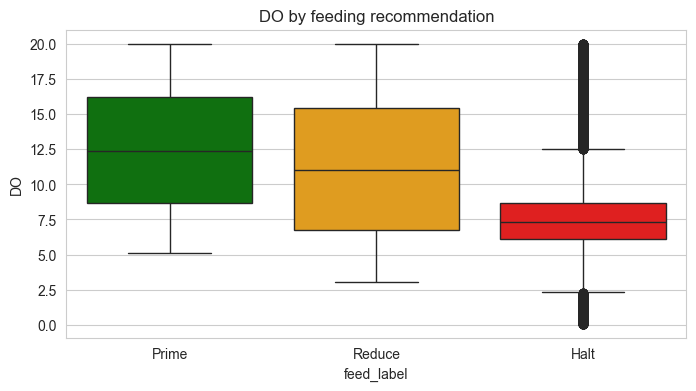

C:\Users\FLORENCE O. ADUOMI\AppData\Local\Temp\ipykernel_3492\929118055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='feed_label', y=col, palette=['green','orange','red'])


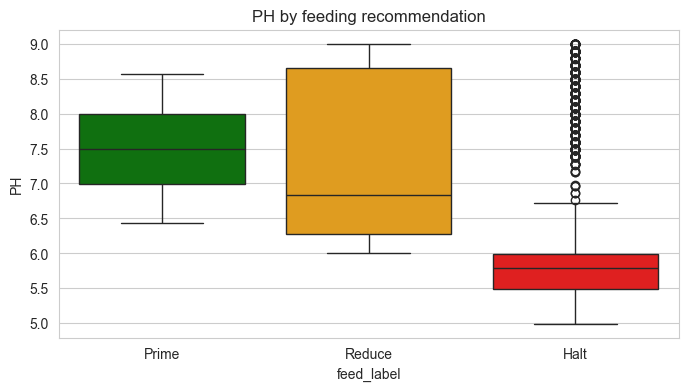

C:\Users\FLORENCE O. ADUOMI\AppData\Local\Temp\ipykernel_3492\929118055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='feed_label', y=col, palette=['green','orange','red'])


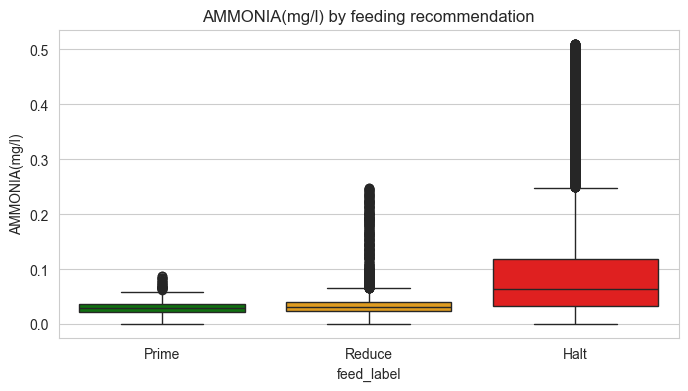

C:\Users\FLORENCE O. ADUOMI\AppData\Local\Temp\ipykernel_3492\929118055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='feed_label', y=col, palette=['green','orange','red'])


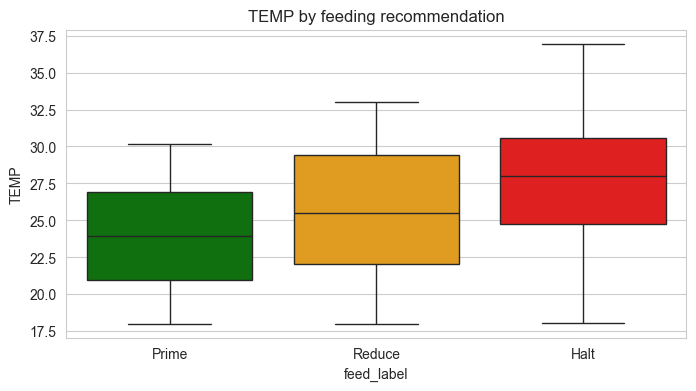

C:\Users\FLORENCE O. ADUOMI\AppData\Local\Temp\ipykernel_3492\929118055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='feed_label', y=col, palette=['green','orange','red'])


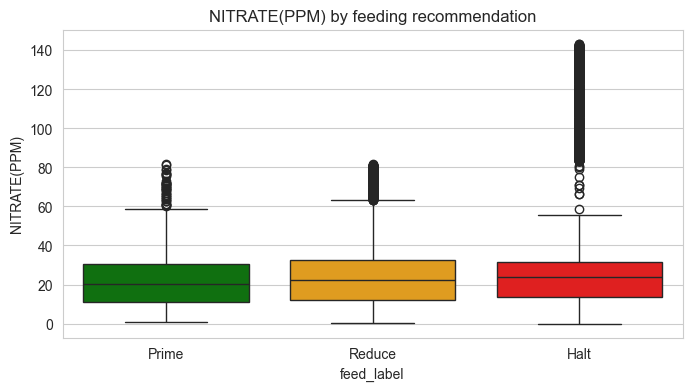

C:\Users\FLORENCE O. ADUOMI\AppData\Local\Temp\ipykernel_3492\929118055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='feed_label', y=col, palette=['green','orange','red'])


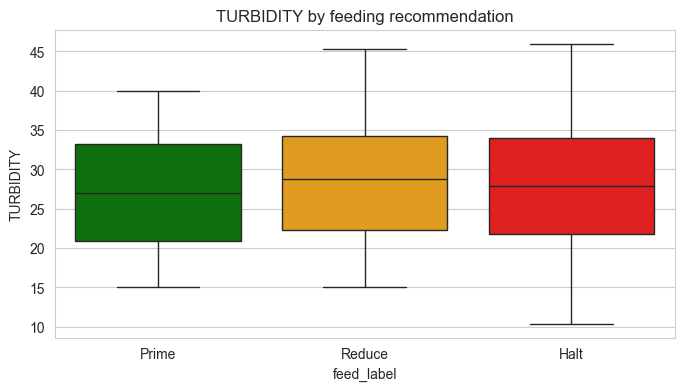

In [19]:
for col in sensor_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='feed_label', y=col, palette=['green','orange','red'])
    plt.title(f'{col} by feeding recommendation')
    plt.xticks([0,1,2], ['Prime','Reduce','Halt'])
    plt.ylabel(col)
    plt.show()

## 7. Pairwise Relationships (Coloured by Label)
A pairplot reveals **how pairs of sensors relate to each other** and whether those relationships differ across feeding label classes. It helps identify:
- Which sensor combinations **best separate** the three classes
- Whether any two sensors are **redundant** (highly correlated)
- The presence of **non-linear patterns** that a model must account for


### Observations

#### DO vs Other Sensors
DO shows the **strongest class separation** when plotted against most other sensors. Prime (blue) and Halt (orange) clusters are visibly distinct, particularly in the DO vs TEMP and DO vs PH scatter plots. This confirms DO as a **highly discriminating feature**.

#### PH vs Other Sensors
PH pairs moderately well with DO and AMMONIA in separating classes. However, considerable overlap exists between Reduce and Halt clusters, suggesting PH alone is insufficient to distinguish these two classes but contributes meaningfully in combination with other sensors.

#### AMMONIA vs Other Sensors
AMMONIA displays **diffuse, overlapping clusters** across all three labels in most pairings. The classes are not cleanly separated, indicating AMMONIA may have **lower standalone predictive power**, though it may still contribute in a multivariate model.

#### TEMP vs Other Sensors
TEMP exhibits moderate separation, particularly when paired with DO. The distribution of Prime conditions tends toward a narrower temperature range, while Halt conditions are more spread out, suggesting temperature variability may be a contributing stress indicator.

#### NITRATE vs Other Sensors
NITRATE shows **wide, overlapping scatter** across all classes in most pairings. The lack of clear cluster boundaries suggests NITRATE may be a **weaker individual predictor**, though interactions with other variables could still be informative.

#### TURBIDITY vs Other Sensors
TURBIDITY displays some class separation, particularly against DO and TEMP. The diagonal histogram confirms that Prime conditions tend toward lower turbidity values, while Halt conditions exhibit a wider spread with higher turbidity readings — consistent with domain expectations for poor water quality.

---

### Diagonal Histograms
The diagonal shows the **marginal distribution** of each sensor per class. Key takeaways:
- **DO** — the three classes have clearly offset distributions, further confirming its discriminating strength
- **TURBIDITY** — some separation visible, with Prime skewed toward lower values
- **AMMONIA and NITRATE** — distributions heavily overlap across classes

---

### General Observations
- No single sensor pair **perfectly separates** all three classes, confirming that a **multivariate model** is necessary
- The Prime class (blue) is generally the most distinct, while Reduce and Halt overlap more frequently — consistent with earlier boxplot findings
- Several sensor pairs show **dense rectangular scatter** rather than elliptical clusters, suggesting the relationships may be **non-linear or weakly correlated**

---

### Recommendation

> The pairplot confirms that **DO is the most informative single feature**, followed by TEMP and TURBIDITY. AMMONIA and NITRATE show limited pairwise separation but should not be discarded — tree-based models (e.g. Random Forest, XGBoost) can capture complex interactions between weakly separating features. Consider **feature importance analysis** post-training to validate which sensors contribute most to model decisions.

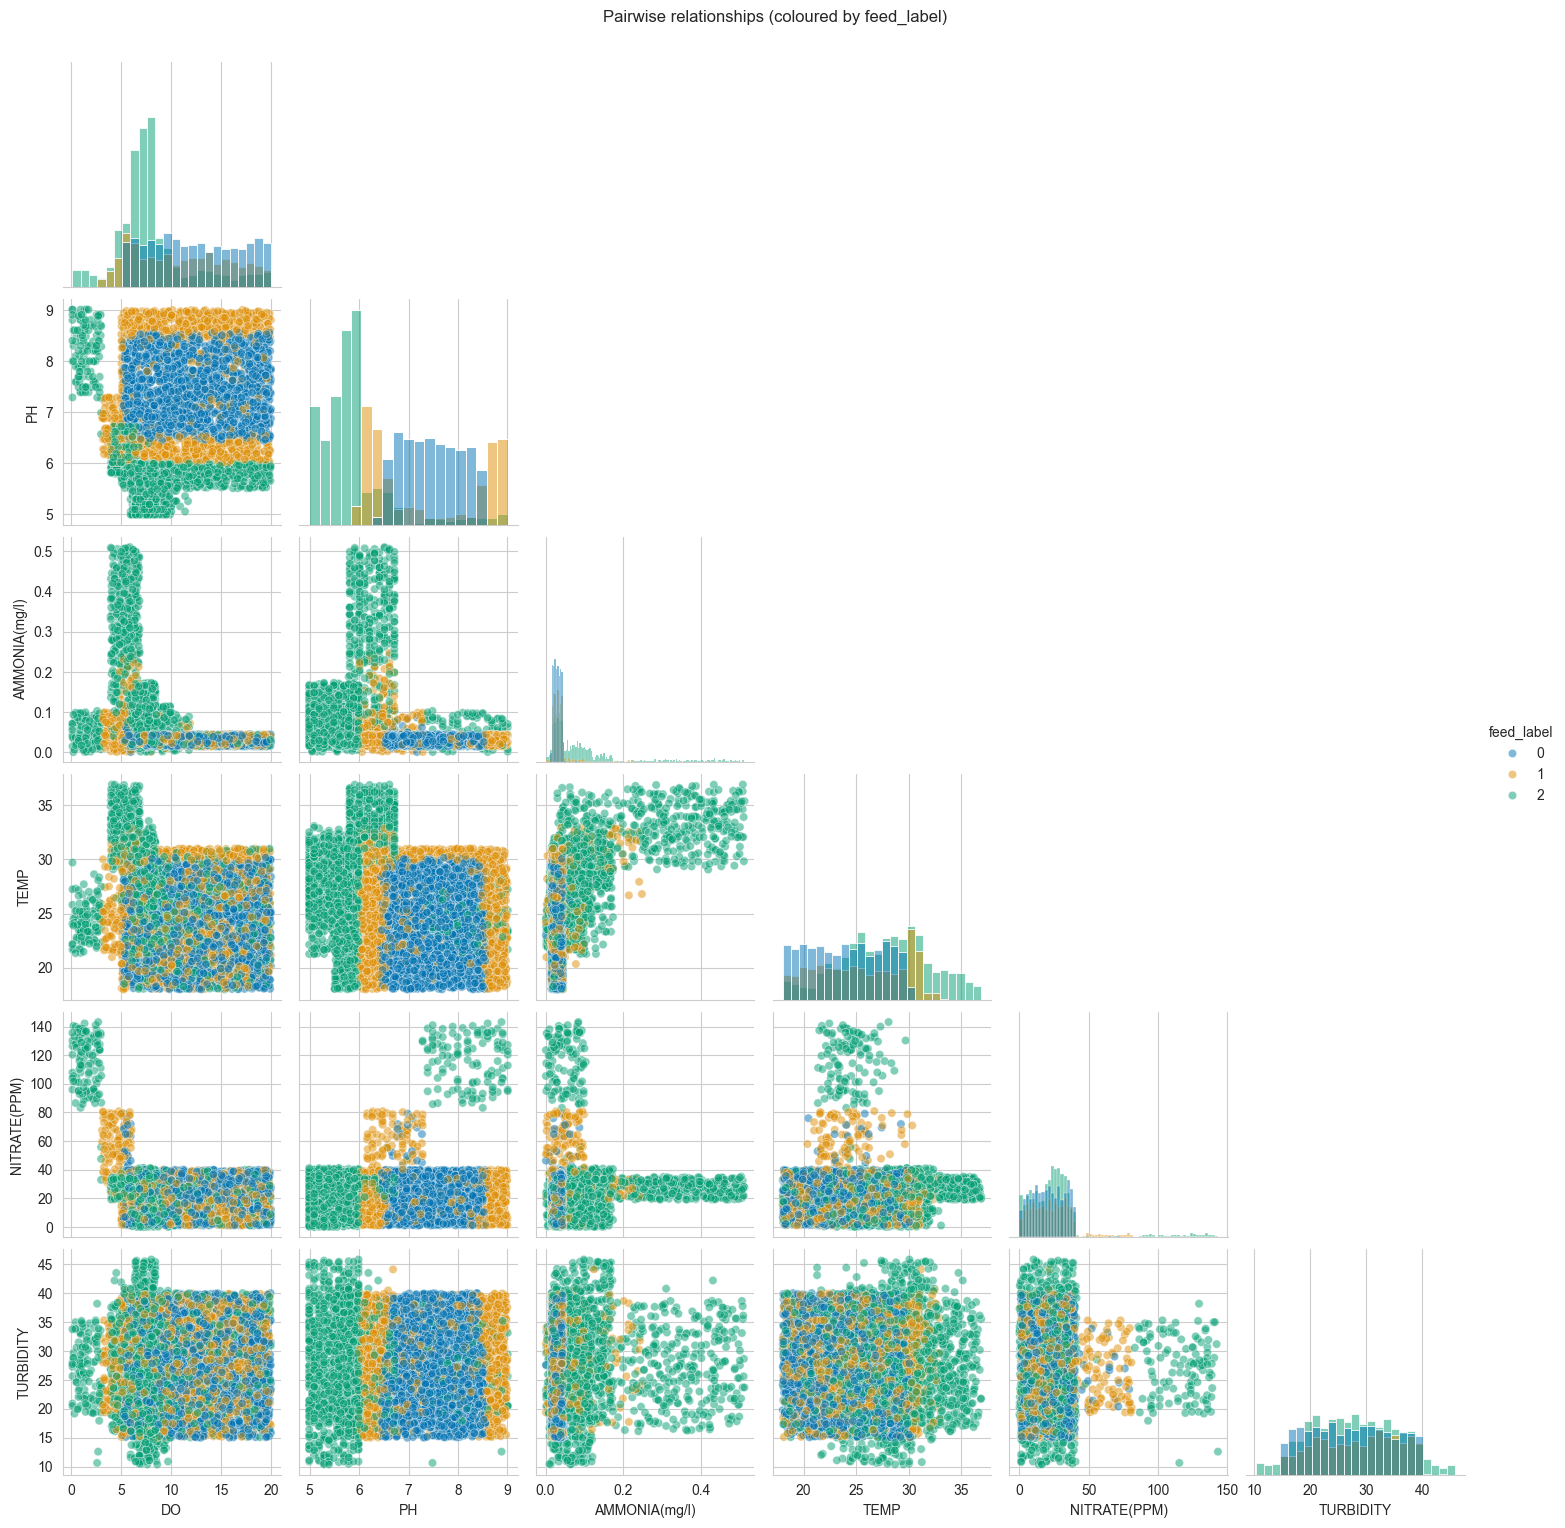

In [21]:
sample_pair = df.sample(5000, random_state=RANDOM_SEED)[sensor_cols + ['feed_label']]
sns.pairplot(sample_pair, hue='feed_label', palette='colorblind',
             diag_kind='hist', plot_kws={'alpha':0.5}, corner=True)
plt.suptitle('Pairwise relationships (coloured by feed_label)', y=1.02)
plt.show()

## 8. Missing Data Patterns (Verification)

Before modelling, it is essential to confirm that **no missing (NaN) values remain** in the dataset. Missing values can silently distort model training, cause runtime errors, or introduce bias if imputed incorrectly. This verification step confirms the effectiveness of the data cleaning pipeline applied in the preceding notebook (`01_data_cleaning_and_label_generation.ipynb`).


### Method
The `missingno` matrix plot visualises the **presence and absence of data** across all sensor columns:
- **Dark filled bars** → data is present
- **White gaps** → missing values

The matrix was applied across all six sensor columns:
`DO`, `PH`, `AMMONIA(mg/l)`, `TEMP`, `NITRATE(PPM)`, `TURBIDITY`

---

### Findings

| Sensor | Missing Values |
|--------|---------------|
| DO | None |
| PH | None |
| AMMONIA(mg/l) | None |
| TEMP | None |
| NITRATE(PPM) | None |
| TURBIDITY | None |

The missingness matrix is **completely solid** with no white gaps detected across any column or row. This confirms that all missing values were successfully handled during the cleaning stage.

---

### Interpretation
The data cleaning step — which dropped all rows containing any sensor NaN — has been **fully verified**. The dataset entering the modelling pipeline is complete and requires no further imputation or missing value treatment.

---

### Recommendation

> No missing value handling is required at this stage. The dataset is clean and ready for feature engineering and model training. If new data is ingested in future (e.g. live sensor streams), a **missing value check should be re-run** as part of the preprocessing pipeline to catch any gaps introduced by sensor dropouts or transmission errors.

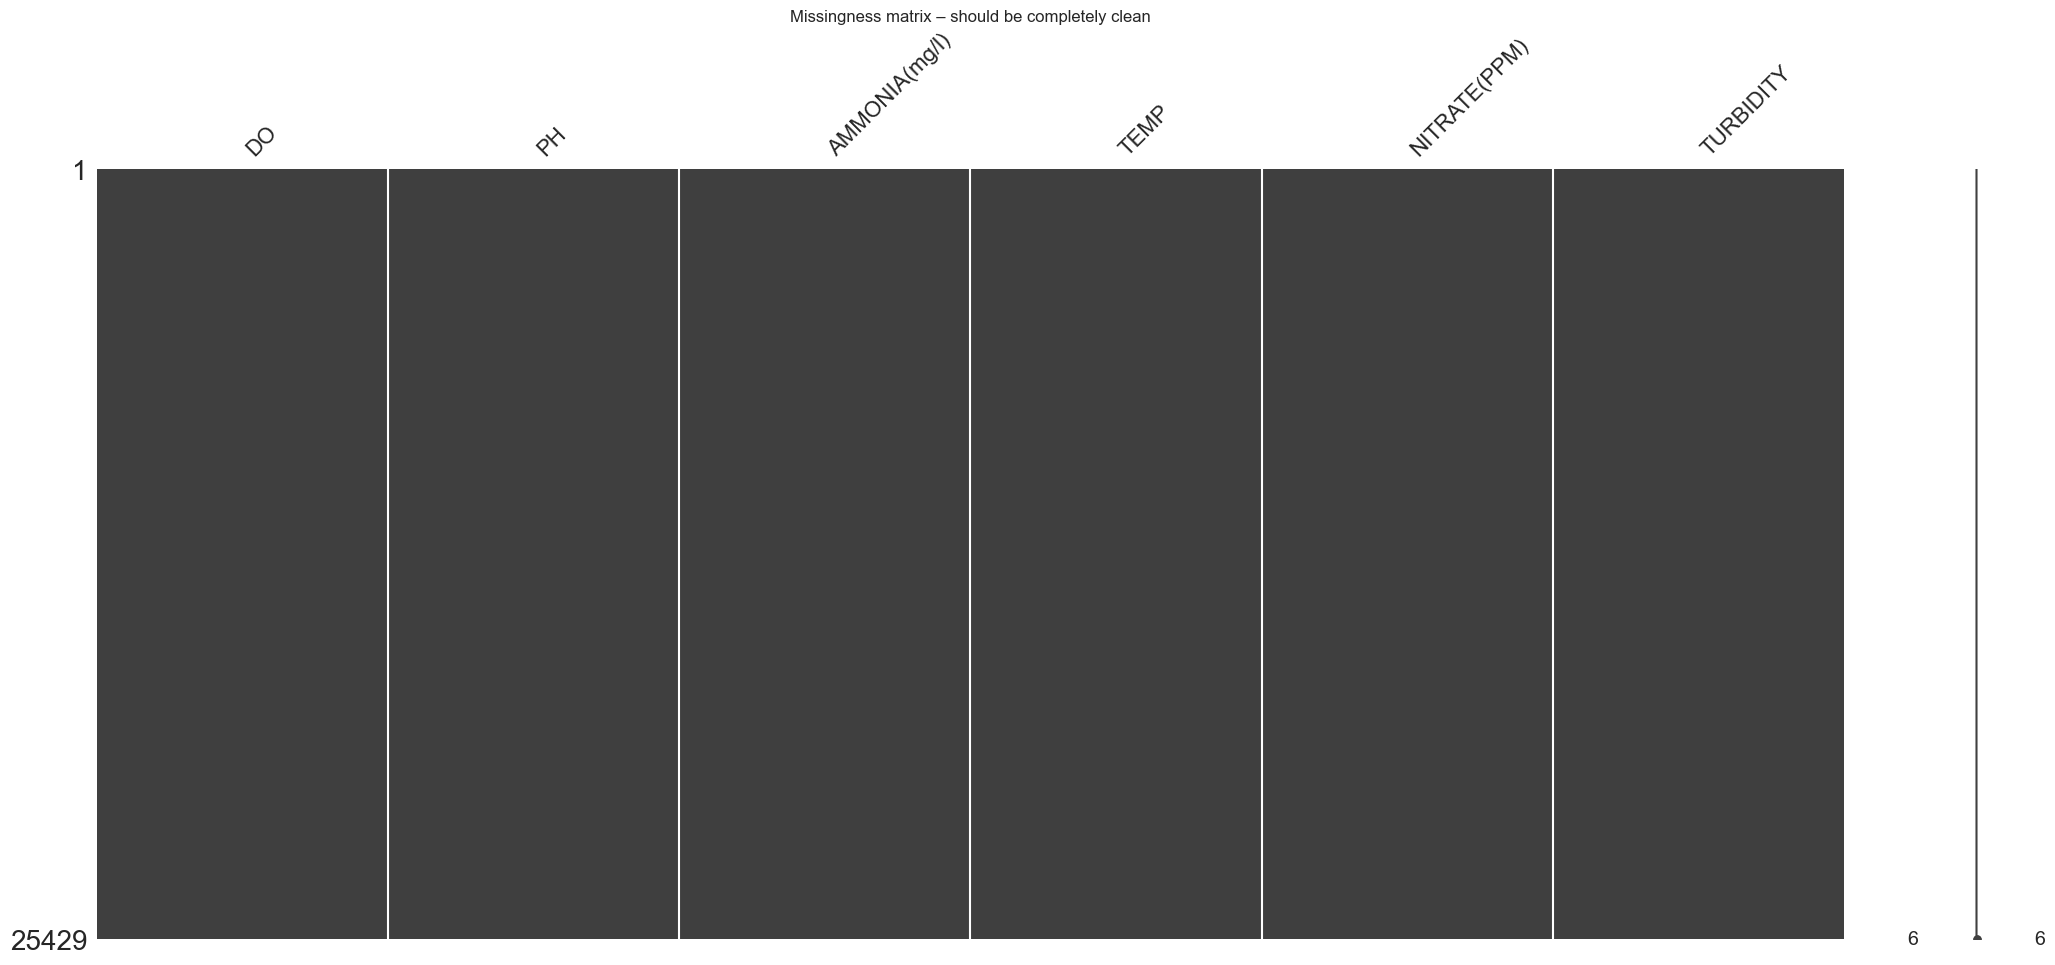

In [22]:
msno.matrix(df[sensor_cols])
plt.title('Missingness matrix – should be completely clean')
plt.show()

## Summary Statistics by Feed Label
# Exploratory Data Analysis

## 5. Summary Statistics by Feed Label

### Why This Matters
Grouped summary statistics provide a **numerical confirmation** of what the boxplots showed visually. By comparing the mean and standard deviation of each sensor across the three feeding labels, we can quantify exactly how much sensor readings differ between classes — and identify which sensors are the most reliable discriminators.

---

### Summary Table

| Feed Label | DO mean | DO std | PH mean | PH std | AMMONIA mean | AMMONIA std | TEMP mean | TEMP std |
|------------|---------|--------|---------|--------|--------------|-------------|-----------|----------|
| 0 – Prime  | 12.43   | 4.32   | 7.50    | 0.58   | 0.03         | 0.01        | 23.94     | 3.46     |
| 1 – Reduce | 11.26   | 4.83   | 7.35    | 1.15   | 0.04         | 0.03        | 25.46     | 4.05     |
| 2 – Halt   | 7.98    | 3.83   | 5.89    | 0.74   | 0.11         | 0.11        | 27.76     | 4.19     |

---

### Sensor-by-Sensor Interpretation

#### DO (Dissolved Oxygen)
- Mean drops consistently: **12.43 → 11.26 → 7.98** from Prime to Halt
- A difference of **~4.45 mg/L** between Prime and Halt is substantial and ecologically significant
- Standard deviation is similar across classes (~3.8–4.8), meaning the separation is driven by the **mean shift**, not variability
- **Strong discriminating feature** ✅

#### PH
- Mean decreases from **7.50 → 7.35 → 5.89** across labels
- The sharp drop to **5.89 in Halt** indicates highly acidic conditions — a genuine water quality alarm signal
- Standard deviation in Reduce (1.15) is notably higher than Prime (0.58), suggesting **unstable PH during transitional conditions**
- **Strong discriminating feature**, particularly for identifying the Halt class ✅

#### AMMONIA (mg/l)
- Mean rises from **0.03 → 0.04 → 0.11** across labels
- While the absolute values are small, the **3.7× increase** from Prime to Halt is ecologically meaningful — elevated ammonia is toxic to aquatic life
- The high standard deviation in Halt (0.11 — equal to the mean) indicates **high variability and extreme spikes** in poor water conditions
- **Moderately discriminating feature**, with most power at the Halt boundary ✅

#### TEMP (°C)
- Mean rises gradually: **23.94 → 25.46 → 27.76** across labels
- Higher temperatures are associated with lower oxygen solubility, which aligns with the simultaneous drop in DO
- Standard deviation increases slightly toward Halt, suggesting **more erratic temperatures** under poor conditions
- **Moderate discriminating feature** — likely acts in combination with DO rather than independently ✅


### Key Takeaways

| Sensor | Direction Across Prime → Halt | Discriminating Power |
|--------|-------------------------------|----------------------|
| DO | ↓ Decreases strongly | High |
| PH | ↓ Decreases strongly at Halt | High |
| AMMONIA | ↑ Increases, especially at Halt | Moderate |
| TEMP | ↑ Increases gradually | Moderate |


### Recommendation

> The summary statistics **numerically validate** the label generation logic. All four visible sensors shift meaningfully across feeding classes in the expected direction, confirming the labels are **physiologically grounded**. DO and PH show the clearest separation and should be expected to rank highly in feature importance. AMMONIA and TEMP provide complementary signals, particularly for distinguishing the Halt class from the other two.

In [23]:
summary = df.groupby('feed_label')[sensor_cols].agg(['mean', 'std']).round(2)
summary.columns = ['_'.join(col) for col in summary.columns]
summary

,DO_mean,DO_std,PH_mean,PH_std,AMMONIA(mg/l)_mean,AMMONIA(mg/l)_std,TEMP_mean,TEMP_std,NITRATE(PPM)_mean,NITRATE(PPM)_std,TURBIDITY_mean,TURBIDITY_std
feed_label,,,,,,,,,,,,
0,12.43,4.32,7.50,0.58,0.03,0.01,23.94,3.46,20.80,11.78,27.15,7.13
1,11.26,4.83,7.35,1.15,0.04,0.03,25.46,4.05,23.75,15.21,28.30,7.07
2,7.98,3.83,5.89,0.74,0.11,0.11,27.76,4.19,27.61,25.96,27.99,7.69
